In [25]:
!pip install yfinance matplotlib

In [26]:
!pip install seaborn 

In [27]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Let's pull data for Google (GOOG) for the last 2 years
ticker = "GOOGL"
data = yf.download(ticker, period="2y", interval="1d")

# Printing the latest 5 rows!
print(data.tail(5))

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker           GOOGL       GOOGL       GOOGL       GOOGL      GOOGL
Date                                                                 
2026-06-25  343.709991  345.570007  335.839996  336.730011   44491400
2026-06-26  337.390015  346.359985  330.200012  342.549988  114706300
2026-06-29  353.649994  354.350006  340.670013  341.829987   34213900
2026-06-30  357.369995  358.619995  350.399994  353.869995   35237200
2026-07-01  361.209991  362.970001  356.429993  358.369995   26687500


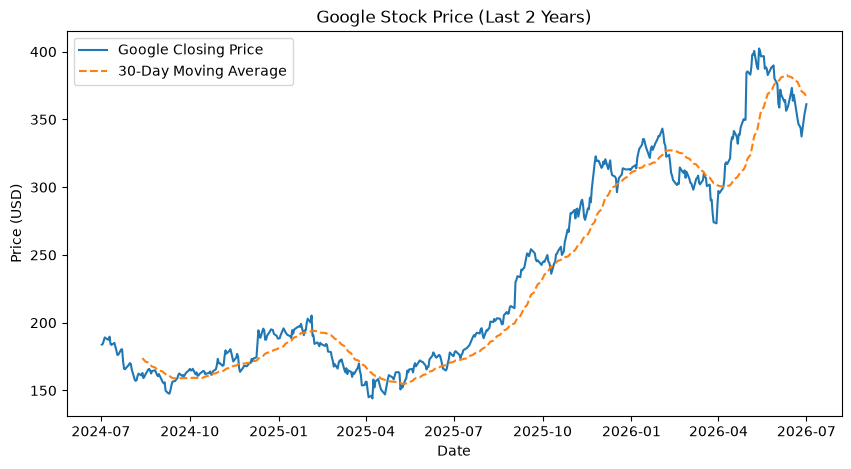

In [28]:
# Plotting the 'Close' price
plt.figure(figsize=(10, 5))
plt.plot(data['Close'], label='Google Closing Price')
plt.title('Google Stock Price (Last 2 Years)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
data['MA30'] = data['Close'].rolling(window=30).mean()
plt.plot(data['MA30'], label='30-Day Moving Average', linestyle='--')
plt.legend()
plt.show()

[*********************100%***********************]  2 of 2 completed


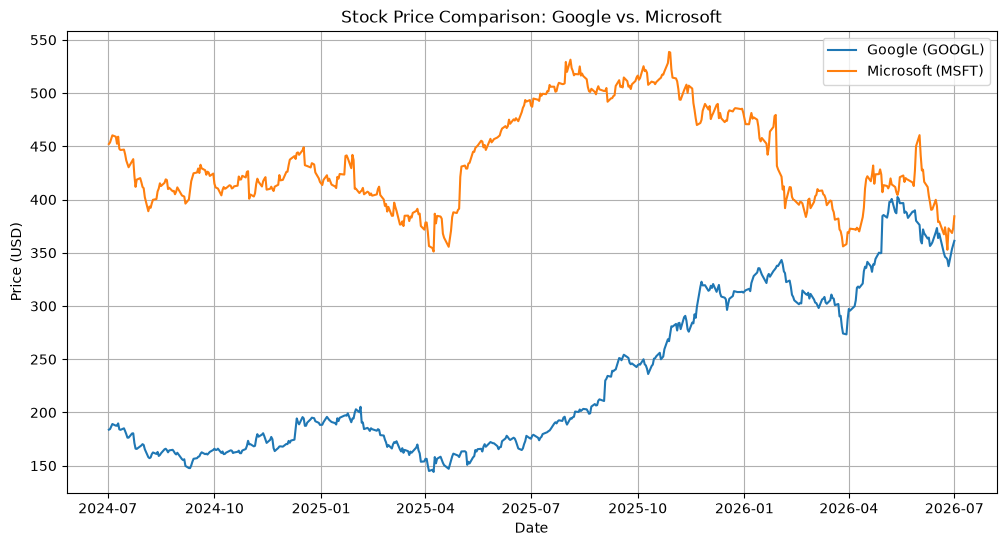

In [29]:
# Compare Google and Microsoft
tickers = ["GOOGL", "MSFT"]
data = yf.download(tickers, period="2y", interval="1d")['Close']

# Plotting both
plt.figure(figsize=(12, 6))
plt.plot(data['GOOGL'], label='Google (GOOGL)')
plt.plot(data['MSFT'], label='Microsoft (MSFT)')

plt.title('Stock Price Comparison: Google vs. Microsoft')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

[*********************100%***********************]  2 of 2 completed


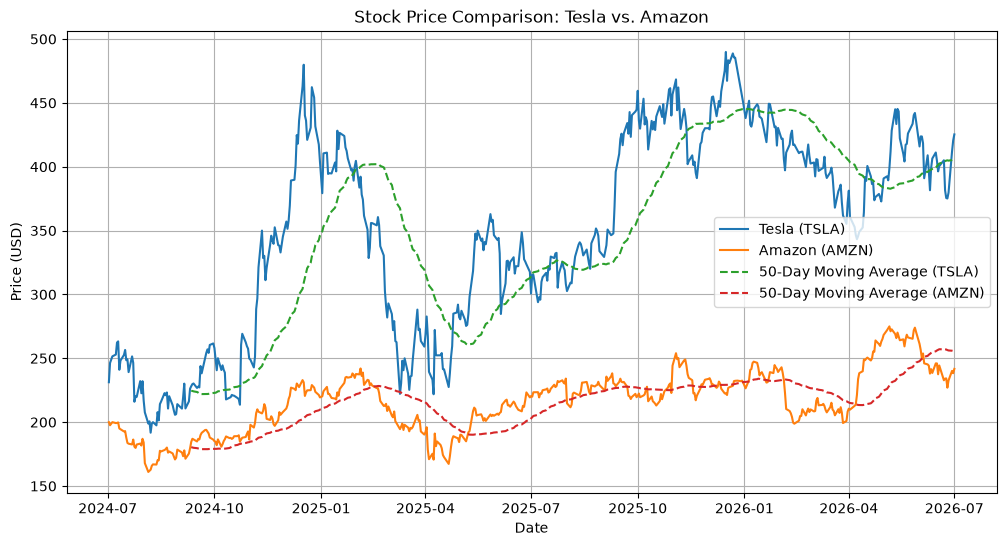

In [30]:
#Compare between Tesla and Amazon" 
tickers = ["TSLA", "AMZN"]
data = yf.download(tickers, period="2y", interval="1d")['Close']

# Plotting both
plt.figure(figsize=(12, 6))
plt.plot(data['TSLA'], label='Tesla (TSLA)')
plt.plot(data['AMZN'], label='Amazon (AMZN)')

plt.title('Stock Price Comparison: Tesla vs. Amazon')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
data['MA50TSLA'] = data['TSLA'].rolling(window=50).mean()
plt.plot(data['MA50TSLA'], label='50-Day Moving Average (TSLA)', linestyle='--')
data['MA50AMZN'] = data['AMZN'].rolling(window=50).mean()
plt.plot(data['MA50AMZN'], label='50-Day Moving Average (AMZN)', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()


[*********************100%***********************]  5 of 5 completed


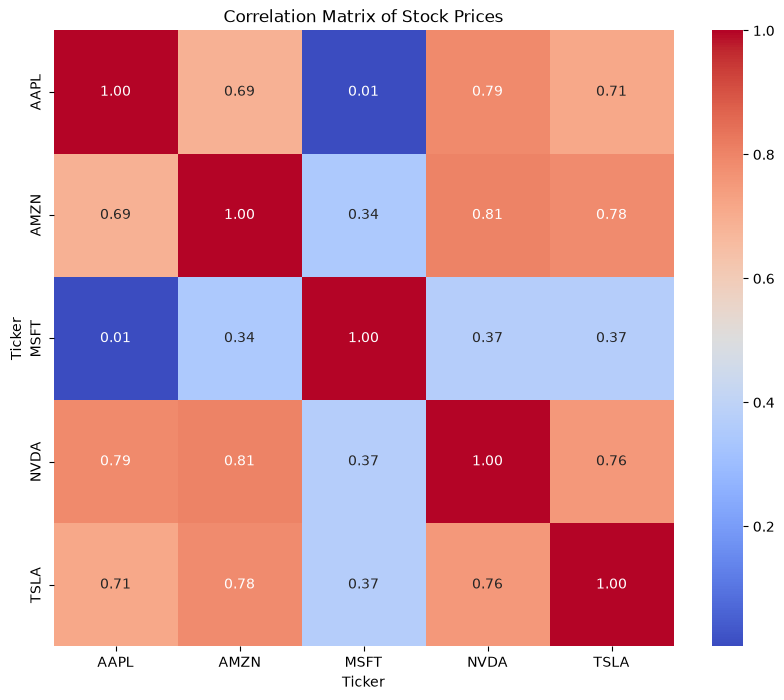

In [31]:
#Creating a heatmap to visualize the correlation between the stocks
tickers = ["TSLA", "AMZN", "AAPL", "MSFT", "NVDA"]
data = yf.download(tickers, period="2y", interval="1d")['Close']
# Calculate the correlation matrix
correlation_matrix = data.corr()
# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Stock Prices")
plt.show()
            

In [32]:
# 1. Calculate the moving averages
data['MA50'] = data['TSLA'].rolling(window=50).mean()
data['MA200'] = data['TSLA'].rolling(window=200).mean()

# 2. Logic to detect the latest signal
# We look at the very last row of our data
last_ma50 = data['MA50'].iloc[-1]
last_ma200 = data['MA200'].iloc[-1]

# 3. Simple decision logic
if last_ma50 > last_ma200:
    print("Signal for TSLA: BULLISH (Price is in an uptrend)")
else:
    print("Signal for TSLA: BEARISH (Price is in a downtrend)")

Signal for TSLA: BEARISH (Price is in a downtrend)


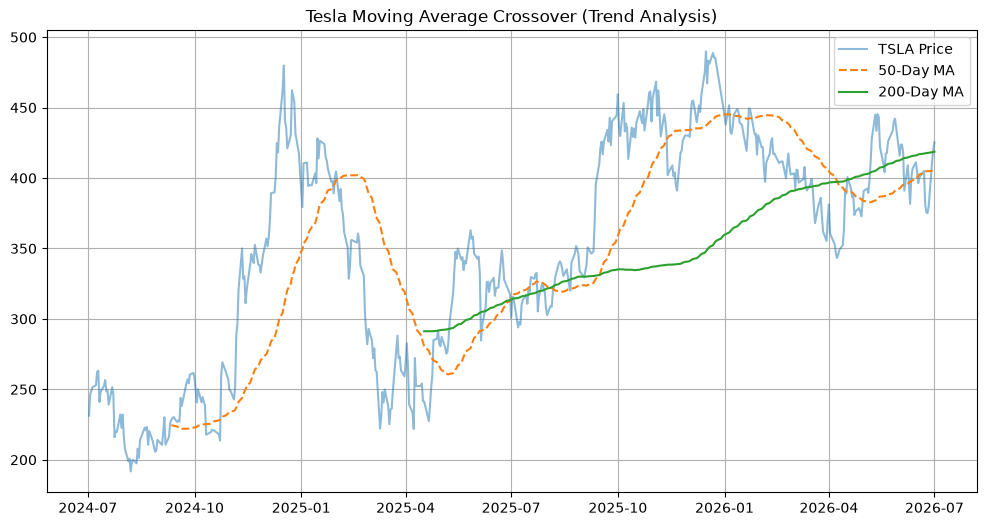

In [33]:
plt.figure(figsize=(12, 6))
# Plotting the raw price, MA50, and MA200
plt.plot(data['TSLA'], label='TSLA Price', alpha=0.5)
plt.plot(data['MA50'], label='50-Day MA', linestyle='--')
plt.plot(data['MA200'], label='200-Day MA', linestyle='-')

plt.title('Tesla Moving Average Crossover (Trend Analysis)')
plt.legend()
plt.grid(True)
plt.show()

KeyError: 'Volume'

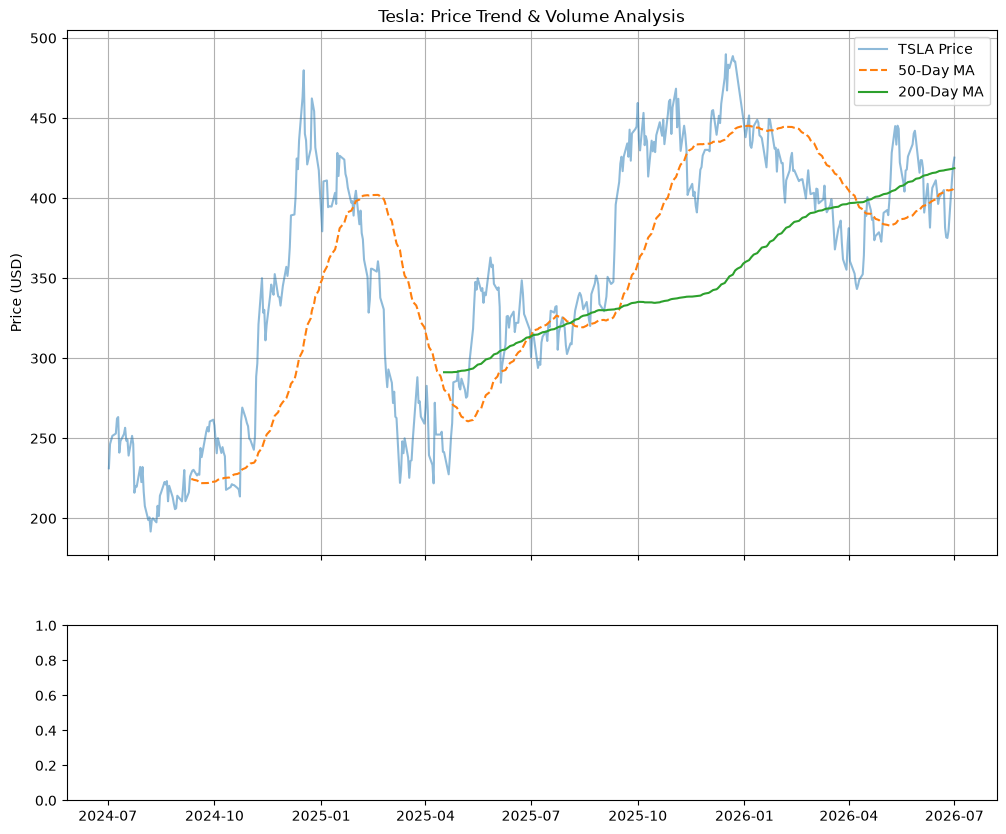

In [ ]:
# Create a figure with two subplots, sharing the same x-axis (Date)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# --- Panel 1: Price and Moving Averages ---
ax1.plot(data['TSLA'], label='TSLA Price', alpha=0.5)
ax1.plot(data['MA50'], label='50-Day MA', linestyle='--')
ax1.plot(data['MA200'], label='200-Day MA', linestyle='-')
ax1.set_title('Tesla: Price Trend & Volume Analysis')
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.grid(True)

# --- Panel 2: Volume ---
# Volume data is usually large, so this shows it in a separate sub-chart
data_tsla = yf.download("TSLA", period="2y", interval="1d")
ax2.bar(data_tsla.index, data_tsla['Volume'], color='gray', alpha=0.3)
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')
ax2.grid(True)

plt.tight_layout()
plt.show()